# OER screening results: O*/OH* adsorption energies, activity volcano, and candidate ranking

This notebook works from a frozen snapshot of the DREAMS OER-screening experiment log,
`explog.pkl` (sitting next to this notebook). It:

1. Rebuilds the `Explog` relational frame (`candidates` + `processes` tables) around the snapshot.
2. Pulls per-adsorption-site ΔG(O*) and ΔG(OH*) free energies out of each candidate's
   `OER_catalyst_study` object.
3. Plots the O* adsorption-energy distribution on its own, then overlays (ΔG(OH*), ΔG(O*))
   pairs on an OER activity volcano — the same Nørskov-style CHE model (equilibrium potential,
   universal OH-OOH scaling relation) used in `plotting.py` from the Zr2ON2 OER paper.
4. Builds a ranked leaderboard of candidates by overpotential, demonstrating a few different
   ways to sort/filter it.

Read-only: this only loads `explog.pkl` and never touches the live workflow (see
`workflow_audit/README.md` for why that separation matters).

In [ ]:
import pickle
import tempfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Categorical colours reused across the figures below.
BLUE, ORANGE, MUTED = "#2a78d6", "#eb6834", "#898781"

## 1. Load the explog snapshot

`explog.pkl` is a pickled `{"candidates_df", "processes_df"}` pair — the two tables behind
`Explog`'s relational frame. We assign them onto a fresh `Explog` instance and recompute only
`_recompute_candidate_progress` (a pure pandas pass over the tables already in memory).

We deliberately do **not** call `EXPLOG.update_log()`: that method polls `squeue` and reads
VASP output directories on the HPC side, neither of which exist here.

In [ ]:
from gnome_dreams_oer_screening import Explog

EXPLOG_PKL = Path("explog.pkl")

with open(EXPLOG_PKL, "rb") as f:
    payload = pickle.load(f)  # {"candidates_df", "processes_df"}

EXPLOG = Explog()
EXPLOG.init(Path(tempfile.mkdtemp(prefix="explog_probe_")), mode="test")
EXPLOG.relational_frame.candidates.df = payload["candidates_df"]
EXPLOG.relational_frame.processes.df = payload["processes_df"]

EXPLOG.job_handler._recompute_candidate_progress()

candidates = EXPLOG.relational_frame.candidates.df
n_active = (candidates["state"] == "active").sum()
n_failed = (candidates["state"] == "failed").sum()
print(f"{len(candidates)} candidates loaded: {n_active} active, {n_failed} failed")
candidates[["candidate_id", "Reduced Formula", "state", "decision",
            "Overpotential_from_scaling", "idealOverPotential"]].head()

139 candidates loaded: 127 active, 12 failed


,candidate_id,Reduced Formula,state,decision,Overpotential_from_scaling,idealOverPotential
0,083fef92df,Fe(PtO3)2,active,Sufficient,0.44,0.19
1,6ace913656,TiSeO5,failed,Abandon,<NA>,<NA>
2,8ef62845e6,NiSe2O7,active,Sufficient,1.14,0.42
3,54d55ba8f4,CoBiTeO6,active,Sufficient,0.77,0.77
4,01ca2e7942,Zn3Ni(SeO4)4,active,Abandon,<NA>,<NA>


## 2. Flatten per-site ΔG(O*) / ΔG(OH*) energies

Each candidate's `study_obj` is an `OER_catalyst_study`. `get_surface_studies()` returns one
`OER_surface_study` per explored surface termination, and each surface study's
`get_adsorption_sites_df()` is a per-adsorption-site table that already carries `G(O)`, `G(OH)`,
and both overpotential definitions — computed live on the HPC before this snapshot was taken.
We concatenate all of these into one long site-level table, tagged with the candidate id and
reduced formula.

In [ ]:
def collect_site_energies(candidates_df):
    numeric_cols = ["G(O)", "G(O) deviation", "G(OH)", "G(OH) deviation",
                     "G(OOH) from scaling relation", "G(OOH, scaling) deviation",
                     "ideal overpotential", "overpotential from OH-OOH scaling relation"]
    rows = []
    for _, cand in candidates_df.iterrows():
        study = cand["study_obj"]
        if study is None:
            continue
        for term_idx, surf_study in study.get_surface_studies().items():
            site_df = surf_study.get_adsorption_sites_df()
            if site_df is None or len(site_df) == 0:
                continue
            site_df = site_df.copy()
            site_df.insert(0, "candidate_id", cand["candidate_id"])
            site_df.insert(1, "Reduced Formula", cand["Reduced Formula"])
            site_df.insert(2, "termination", term_idx)
            rows.append(site_df)

    sites = pd.concat(rows, ignore_index=True)
    for col in numeric_cols:
        sites[col] = pd.to_numeric(sites[col], errors="coerce")
    return sites


sites_df = collect_site_energies(candidates)
print(f"{len(sites_df)} adsorption sites across {sites_df['candidate_id'].nunique()} candidates")
sites_df[["candidate_id", "Reduced Formula", "termination", "Site index",
          "site type", "G(O)", "G(OH)",
          "overpotential from OH-OOH scaling relation"]].head(10)

714 adsorption sites across 118 candidates


,candidate_id,Reduced Formula,termination,Site index,site type,G(O),G(OH),overpotential from OH-OOH scaling relation
0,083fef92df,Fe(PtO3)2,13,0,on-top,3.791946,1.279877,1.28
1,083fef92df,Fe(PtO3)2,13,1,on-top,NaN,NaN,NaN
2,083fef92df,Fe(PtO3)2,12,0,on-top,NaN,NaN,NaN
3,083fef92df,Fe(PtO3)2,12,1,on-top,2.323414,0.794344,0.44
4,083fef92df,Fe(PtO3)2,1,0,on-top,4.207451,NaN,NaN
5,083fef92df,Fe(PtO3)2,1,1,on-top,2.078360,0.931293,0.82
6,083fef92df,Fe(PtO3)2,1,3,on-top,2.755121,0.983603,0.54
7,8ef62845e6,NiSe2O7,7,0,on-top,5.151782,NaN,NaN
8,8ef62845e6,NiSe2O7,7,1,on-top,NaN,NaN,NaN
9,8ef62845e6,NiSe2O7,7,2,on-top,NaN,NaN,NaN


## 3. O* adsorption-energy plot

Before combining O* and OH* into a volcano, it's worth looking at the O*-adsorption leg on its
own: how the DFT free energies are distributed, and how far each site sits from the CHE-ideal
value (2.46 eV = ΔG_total / 2 — the ΔG(O*) that makes steps 3 and 4 equally rate-limiting).

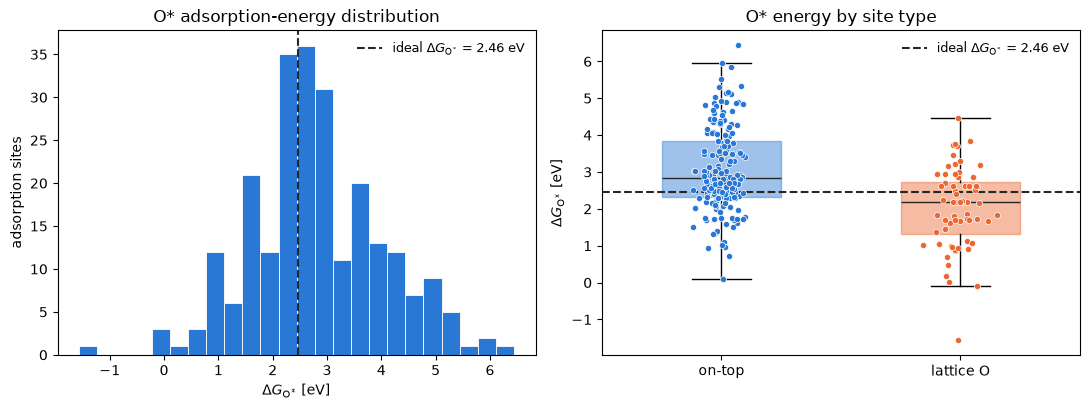

In [ ]:
G_O_IDEAL = 2.46  # eV; OER_adsorption_site_study.OPTIMAL_ADSORPTION_FREE_ENERGIES["O"]

o_sites = sites_df.dropna(subset=["G(O)"])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
ax.hist(o_sites["G(O)"], bins=24, color=BLUE, edgecolor="white", linewidth=0.6)
ax.axvline(G_O_IDEAL, color="0.15", ls="--", lw=1.5,
           label=fr"ideal $\Delta G_{{\mathrm{{O^*}}}}$ = {G_O_IDEAL} eV")
ax.set_xlabel(r"$\Delta G_{\mathrm{O^*}}$ [eV]")
ax.set_ylabel("adsorption sites")
ax.set_title("O* adsorption-energy distribution")
ax.legend(frameon=False, fontsize=9)

ax = axes[1]
site_types = ["on-top", "lattice O"]
colors = [BLUE, ORANGE]
groups = [o_sites.loc[o_sites["site type"] == t, "G(O)"].dropna() for t in site_types]

bplot = ax.boxplot(groups, tick_labels=site_types, patch_artist=True, widths=0.5,
                    showfliers=False, medianprops=dict(color="0.15"))
for patch, color in zip(bplot["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.45)
    patch.set_edgecolor(color)

rng = np.random.default_rng(0)
for i, (group, color) in enumerate(zip(groups, colors), start=1):
    jitter = rng.normal(i, 0.05, size=len(group))
    ax.scatter(jitter, group, s=20, color=color, edgecolor="white",
               linewidth=0.5, zorder=3)

ax.axhline(G_O_IDEAL, color="0.15", ls="--", lw=1.5,
           label=fr"ideal $\Delta G_{{\mathrm{{O^*}}}}$ = {G_O_IDEAL} eV")
ax.set_ylabel(r"$\Delta G_{\mathrm{O^*}}$ [eV]")
ax.set_title("O* energy by site type")
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

## 4. Best adsorption site per candidate

The volcano and the ranking both need one (ΔG(O*), ΔG(OH*)) pair per candidate, so we reduce
the site-level table to its best site — lowest scaling-relation overpotential — per candidate.
This mirrors how `Job_handler._update_candidate_oer_metrics` fills `Overpotential_from_scaling`
on the candidates table itself ("best available value across all sites"). Only sites with
*both* ΔG(O*) and ΔG(OH*) present are eligible, since the volcano needs both axes.

In [ ]:
both_df = sites_df.dropna(subset=["G(O)", "G(OH)"])

best_site_df = (
    both_df.sort_values("overpotential from OH-OOH scaling relation")
           .groupby("candidate_id", as_index=False)
           .first()
)

leaderboard = best_site_df.merge(
    candidates[["candidate_id", "state", "decision", "max_dG_U[1.2,2.0]_pH0"]],
    on="candidate_id", how="left",
).rename(columns={
    "overpotential from OH-OOH scaling relation": "eta_scaling",
    "ideal overpotential": "eta_ideal",
    "max_dG_U[1.2,2.0]_pH0": "pbx_instability",
})

print(f"{len(leaderboard)} candidates have a site with both G(O) and G(OH)")
leaderboard[["candidate_id", "Reduced Formula", "site type", "G(O)", "G(OH)",
             "eta_scaling", "eta_ideal", "pbx_instability", "decision"]].head(10)

61 candidates have a site with both G(O) and G(OH)


,candidate_id,Reduced Formula,site type,G(O),G(OH),eta_scaling,eta_ideal,pbx_instability,decision
0,018a80a60d,Ag5Ir3O14,on-top,2.407755,0.444372,0.73,0.73,0.066783,Sufficient
1,035e1d6a6e,CoBiPt2O7,on-top,1.750104,1.151618,1.37,0.35,0.120818,Sufficient
2,048588cbb2,MgCo(PtO3)4,on-top,2.925920,1.215257,0.48,0.48,0.081657,Sufficient
3,077f8943bb,Ir2RhO6,on-top,2.290660,0.796355,0.48,0.26,0.036307,Abandon
4,083fef92df,Fe(PtO3)2,on-top,2.323414,0.794344,0.44,0.30,0.002717,Sufficient
5,10e1f3a804,CuIrRhO6,lattice O,2.251497,0.502238,0.52,0.52,0.054483,Medium priority
6,14fdd2c52a,Ru(RhO3)2,on-top,2.473039,0.953857,0.45,0.29,0.412802,Sufficient
7,197e818758,CoCuBiO5,on-top,4.300556,1.960713,1.11,1.11,0.204849,Sufficient
8,235d399972,PrCuTeO6,on-top,2.506671,0.250442,1.03,1.03,0.184369,Abandon
9,2518ad54d1,LaNiIO6,lattice O,2.599363,0.742375,0.63,0.63,0.15355,Sufficient


## 5. OER activity volcano

Model: acidic computational-hydrogen-electrode, U_eq = 1.23 V, ΔG_total = 4.92 eV for
2 H2O → O2 + 4(H+ + e-), and ΔG(OOH*) from the universal scaling relation
ΔG(OOH*) = ΔG(OH*) + 3.2 eV (matching `OER_catalyst_study.OH_OOH_scaling_intercept`'s default).
The theoretical overpotential is the largest of the four electrochemical steps, minus U_eq.

We draw the field on the descriptor axes x = ΔG(O*) − ΔG(OH*), y = ΔG(OH*) (as in
`plotting.py::plot_oer_volcano`), then overlay each candidate's best site. Axis limits are
derived from the 2nd–98th percentile of the data plus padding, so one extreme outlier site
doesn't flatten the whole colour scale; the title reports how many candidates fall outside
that view (they're still in the ranking below).

In [ ]:
U_EQ = 1.23             # equilibrium potential [V]
DELTA_G_TOTAL = 4.92    # 2 H2O -> O2 + 4(H+ + e-) [eV]
OH_OOH_INTERCEPT = 3.2  # OER_catalyst_study.OH_OOH_scaling_intercept default


def scaling_ooh(G_OH, G_O, intercept=OH_OOH_INTERCEPT):
    """OOH from the universal scaling relation: G_OOH = G_OH + intercept."""
    return G_OH + intercept


def ideal_ooh(G_OH, G_O):
    """OOH that minimises the overpotential for given (G_OH, G_O): the O*->OOH*
    and OOH*->O2 steps end up equal, independent of G_OH (see plotting.py)."""
    return (DELTA_G_TOTAL + G_O) / 2.0


def oer_steps(G_OH, G_O, ooh_model=scaling_ooh):
    G_OOH = ooh_model(G_OH, G_O)
    return np.stack([G_OH, G_O - G_OH, G_OOH - G_O, DELTA_G_TOTAL - G_OOH])


def oer_overpotential(G_OH, G_O, ooh_model=scaling_ooh):
    return oer_steps(G_OH, G_O, ooh_model).max(axis=0) - U_EQ


def oer_limiting_step(G_OH, G_O, ooh_model=scaling_ooh):
    return oer_steps(G_OH, G_O, ooh_model).argmax(axis=0)


def robust_limits(values, lo_q=0.02, hi_q=0.98, pad=0.3):
    lo, hi = np.nanquantile(values, [lo_q, hi_q])
    return (lo - pad, hi + pad)


def plot_oer_volcano(ax, xlim, ylim, ooh_model=scaling_ooh,
                      eta_max=1.8, cmap="cividis", resolution=400,
                      limiting_lines=True):
    """Draw only the overpotential field (+ limiting-step contours) into `ax`;
    overlay data points from the caller, same contract as plotting.py."""
    xs = np.linspace(*xlim, resolution)
    ys = np.linspace(*ylim, resolution)
    X, Y = np.meshgrid(xs, ys)      # X = G(O) - G(OH), Y = G(OH)
    G_OH, G_O = Y, X + Y

    eta = oer_overpotential(G_OH, G_O, ooh_model=ooh_model)

    step = 0.1
    lo = np.floor(np.nanmin(eta) / step) * step
    hi = np.ceil(np.nanmax(eta) / step) * step
    if eta_max is not None:
        hi = min(hi, eta_max)
    levels = np.round(lo + step * np.arange(int(round((hi - lo) / step)) + 1), 2)

    extend = "max" if np.nanmax(eta) > levels[-1] + 1e-9 else "neither"
    cf = ax.contourf(X, Y, eta, levels=levels, cmap=cmap, extend=extend)

    if limiting_lines:
        lim = oer_limiting_step(G_OH, G_O, ooh_model=ooh_model)
        ax.contour(X, Y, lim, levels=np.arange(0.5, 4, 1), colors="0.15", linewidths=0.75)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel(r"$\Delta G_{\mathrm{O^*}} - \Delta G_{\mathrm{OH^*}}$ [eV]")
    ax.set_ylabel(r"$\Delta G_{\mathrm{OH^*}}$ [eV]")
    return cf

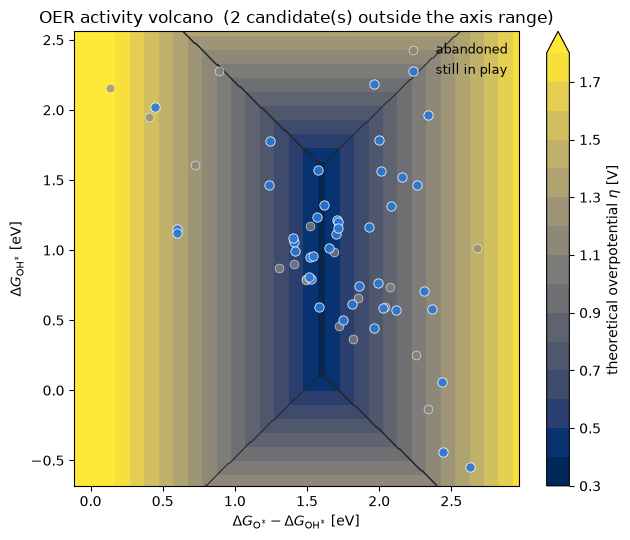

In [ ]:
x_vals = leaderboard["G(O)"] - leaderboard["G(OH)"]
y_vals = leaderboard["G(OH)"]
xlim = robust_limits(x_vals)
ylim = robust_limits(y_vals)
n_outside = int(((x_vals < xlim[0]) | (x_vals > xlim[1]) |
                  (y_vals < ylim[0]) | (y_vals > ylim[1])).sum())

fig, ax = plt.subplots(figsize=(6.5, 5.5))
cf = plot_oer_volcano(ax, xlim=xlim, ylim=ylim)
cbar = fig.colorbar(cf, ax=ax)
cbar.set_label(r"theoretical overpotential $\eta$ [V]")

kept = leaderboard["decision"].fillna("pending") != "Abandon"
ax.scatter(x_vals[~kept], y_vals[~kept], s=40, color=MUTED, alpha=0.7,
           edgecolor="white", linewidth=0.5, label="abandoned", zorder=4)
ax.scatter(x_vals[kept], y_vals[kept], s=45, color=BLUE, alpha=0.9,
           edgecolor="white", linewidth=0.6, label="still in play", zorder=5)

# The 5 candidates closest to the volcano peak naturally cluster together, so we
# name them in the ranking table below (section 6) instead of crowding the plot
# with overlapping direct labels.
ax.set_title(f"OER activity volcano  ({n_outside} candidate(s) outside the axis range)")
ax.legend(frameon=False, fontsize=9, loc="upper right")
fig.tight_layout()
plt.show()

## 6. Ranking candidates by overpotential

`leaderboard` has one row per candidate (its best site). A few ways to sort/filter it:

- by the scaling-relation overpotential (the standard, scaling-relation-constrained metric);
- by the "ideal" overpotential (the loosest possible bound — a sanity-check ceiling, not a
  promise the material can actually reach it);
- restricted to candidates the agent has not already marked `Abandon`;
- a combined activity + stability rank, averaging the overpotential rank with the Pourbaix
  instability rank (`max_dG_U[1.2,2.0]_pH0` — the worst-case decomposition energy across the
  1.2–2.0 V OER window at pH 0; lower means more stable).

In [ ]:
def show_top(df, by, ascending=True, n=10, extra_cols=()):
    cols = ["candidate_id", "Reduced Formula", "site type", "eta_scaling",
            "eta_ideal", "pbx_instability", "state", "decision", *extra_cols]
    return df.sort_values(by, ascending=ascending)[cols].head(n)


print("Top 10 by scaling-relation overpotential (lower = better):")
display(show_top(leaderboard, "eta_scaling"))

print("\nTop 10 by ideal (best-case OOH) overpotential:")
display(show_top(leaderboard, "eta_ideal"))

print("\nTop 10 by scaling overpotential, restricted to candidates the agent hasn't abandoned:")
display(show_top(leaderboard[leaderboard["decision"] != "Abandon"], "eta_scaling"))

print("\nTop 10 by a combined activity + Pourbaix-stability rank:")
ranked = leaderboard.copy()
ranked["combined_rank"] = ranked[["eta_scaling", "pbx_instability"]].rank().mean(axis=1)
display(show_top(ranked, "combined_rank", extra_cols=["combined_rank"]))

Top 10 by scaling-relation overpotential (lower = better):


,candidate_id,Reduced Formula,site type,eta_scaling,eta_ideal,pbx_instability,state,decision
14,3365a319d5,DyCoTeO6,on-top,0.39,0.35,0.117333,active,Sufficient
33,6a284367e9,EuCoIO6,lattice O,0.39,0.39,0.136501,active,Sufficient
51,b32c8db571,LaCoTeO6,lattice O,0.39,0.35,0.1321,active,Sufficient
54,d4d0c07657,Bi3(Rh2O7)2,on-top,0.40,0.34,0.039799,active,Sufficient
13,33095629c4,IrRh5O12,on-top,0.42,0.42,0.002177,active,Low priority
58,eae2b2cd97,Ir(RhO3)2,on-top,0.43,0.31,0.004133,active,High priority
4,083fef92df,Fe(PtO3)2,on-top,0.44,0.30,0.002717,active,Sufficient
6,14fdd2c52a,Ru(RhO3)2,on-top,0.45,0.29,0.412802,active,Sufficient
44,8c6a2c9729,Fe4Ir7RhO24,on-top,0.45,0.29,0.0,active,Abandon
28,623693af7b,Ir3RhO8,on-top,0.46,0.28,0.049644,active,Low priority



Top 10 by ideal (best-case OOH) overpotential:


,candidate_id,Reduced Formula,site type,eta_scaling,eta_ideal,pbx_instability,state,decision
17,3b41721c72,CoBi3(Rh2O7)2,lattice O,0.67,0.14,0.130278,active,Abandon
48,a21b6febda,FeIrRhO6,on-top,0.57,0.17,0.015935,active,Sufficient
42,8a13a827f5,MoIr(RhO3)4,on-top,0.56,0.18,0.149622,active,Abandon
21,47b687b292,GaIr2(RhO4)3,on-top,0.56,0.18,0.022005,active,Sufficient
52,bb34aff8b9,GaIrRhO6,on-top,0.55,0.19,0.046299,active,High priority
35,728d6560b8,EuNiIO6,lattice O,0.73,0.23,0.127449,active,Sufficient
3,077f8943bb,Ir2RhO6,on-top,0.48,0.26,0.036307,active,Abandon
49,a5b715fee8,Ir5RhO12,on-top,0.47,0.27,0.061986,active,Abandon
28,623693af7b,Ir3RhO8,on-top,0.46,0.28,0.049644,active,Low priority
6,14fdd2c52a,Ru(RhO3)2,on-top,0.45,0.29,0.412802,active,Sufficient



Top 10 by scaling overpotential, restricted to candidates the agent hasn't abandoned:


,candidate_id,Reduced Formula,site type,eta_scaling,eta_ideal,pbx_instability,state,decision
14,3365a319d5,DyCoTeO6,on-top,0.39,0.35,0.117333,active,Sufficient
33,6a284367e9,EuCoIO6,lattice O,0.39,0.39,0.136501,active,Sufficient
51,b32c8db571,LaCoTeO6,lattice O,0.39,0.35,0.1321,active,Sufficient
54,d4d0c07657,Bi3(Rh2O7)2,on-top,0.40,0.34,0.039799,active,Sufficient
13,33095629c4,IrRh5O12,on-top,0.42,0.42,0.002177,active,Low priority
58,eae2b2cd97,Ir(RhO3)2,on-top,0.43,0.31,0.004133,active,High priority
4,083fef92df,Fe(PtO3)2,on-top,0.44,0.30,0.002717,active,Sufficient
6,14fdd2c52a,Ru(RhO3)2,on-top,0.45,0.29,0.412802,active,Sufficient
28,623693af7b,Ir3RhO8,on-top,0.46,0.28,0.049644,active,Low priority
23,4ed7b30d93,Zn(PtO3)2,on-top,0.47,0.47,0.114409,active,Sufficient



Top 10 by a combined activity + Pourbaix-stability rank:


,candidate_id,Reduced Formula,site type,eta_scaling,eta_ideal,pbx_instability,state,decision,combined_rank
13,33095629c4,IrRh5O12,on-top,0.42,0.42,0.002177,active,Low priority,3.50
44,8c6a2c9729,Fe4Ir7RhO24,on-top,0.45,0.29,0.0,active,Abandon,4.75
58,eae2b2cd97,Ir(RhO3)2,on-top,0.43,0.31,0.004133,active,High priority,5.00
4,083fef92df,Fe(PtO3)2,on-top,0.44,0.30,0.002717,active,Sufficient,5.00
46,951e8c17c9,FeIr2(RhO4)3,on-top,0.46,0.46,0.005918,active,Abandon,7.75
54,d4d0c07657,Bi3(Rh2O7)2,on-top,0.40,0.34,0.039799,active,Sufficient,8.00
3,077f8943bb,Ir2RhO6,on-top,0.48,0.26,0.036307,active,Abandon,12.25
28,623693af7b,Ir3RhO8,on-top,0.46,0.28,0.049644,active,Low priority,12.25
48,a21b6febda,FeIrRhO6,on-top,0.57,0.17,0.015935,active,Sufficient,14.50
21,47b687b292,GaIr2(RhO4)3,on-top,0.56,0.18,0.022005,active,Sufficient,15.25


## 7. ΔG(O*) audit: raw DFT trend + two volcano models

A different cut of the same data, sharing one axis — ΔG(O*) [eV] — across three panels:

1. every completed O* DFT calculation, plotted against its `process_id` (raw campaign
   chronology — not reduced to one site per candidate);
2. the standard single-descriptor OER volcano: overpotential (colour) as a function of
   ΔG(OH*) (x) and ΔG(O*) (y), using the universal OH-OOH scaling relation
   (`scaling_ooh`, ΔG(OOH*) = ΔG(OH*) + 3.2 eV) — the same model as section 5, just drawn
   directly in the (ΔG(OH*), ΔG(O*)) plane instead of the descriptor-difference plane;
3. the same plane, but with ΔG(OOH*) replaced by its theoretical optimum given ΔG(O*) alone
   (`ideal_ooh`, from `plotting.py`) — the overpotential a site would have if the scaling
   relation weren't constraining OOH* at all, i.e. how much of panel 2's overpotential is
   the scaling relation's "tax" rather than a property of O*/OH* themselves.

Every dot (in all three panels) is coloured by the `process_id` of its O* DFT calculation,
with one shared colour scale on the **left**, so the same colour identifies the same
calculation whether you're looking at its raw chronology (panel 1) or where it lands on a
volcano (panels 2/3). Panels 2 and 3 also share one overpotential colour scale (on the
right, computed from both fields together, using the `jet` colormap) so they're directly
comparable. Every adsorption site with both ΔG(O*) and ΔG(OH*) (`both_df`, not just each
candidate's best site) is overlaid on panels 2 and 3, joined back to its originating
O_adsorption `process_id` via (candidate, termination, site index).

In [ ]:
processes = EXPLOG.relational_frame.processes.df
o_processes = processes.loc[processes["job_type"] == "O_adsorption",
                             ["process_id", "candidate_id", "termination_index",
                              "site_index", "status", "G(O)"]].copy()
o_processes["G(O)"] = pd.to_numeric(o_processes["G(O)"], errors="coerce")
o_processes = o_processes.dropna(subset=["G(O)"]).sort_values("process_id")

print(f"{len(o_processes)} completed O_adsorption DFT calculations "
      f"(process_id {o_processes['process_id'].min()}-{o_processes['process_id'].max()})")

242 completed O_adsorption DFT calculations (process_id 101-1088)


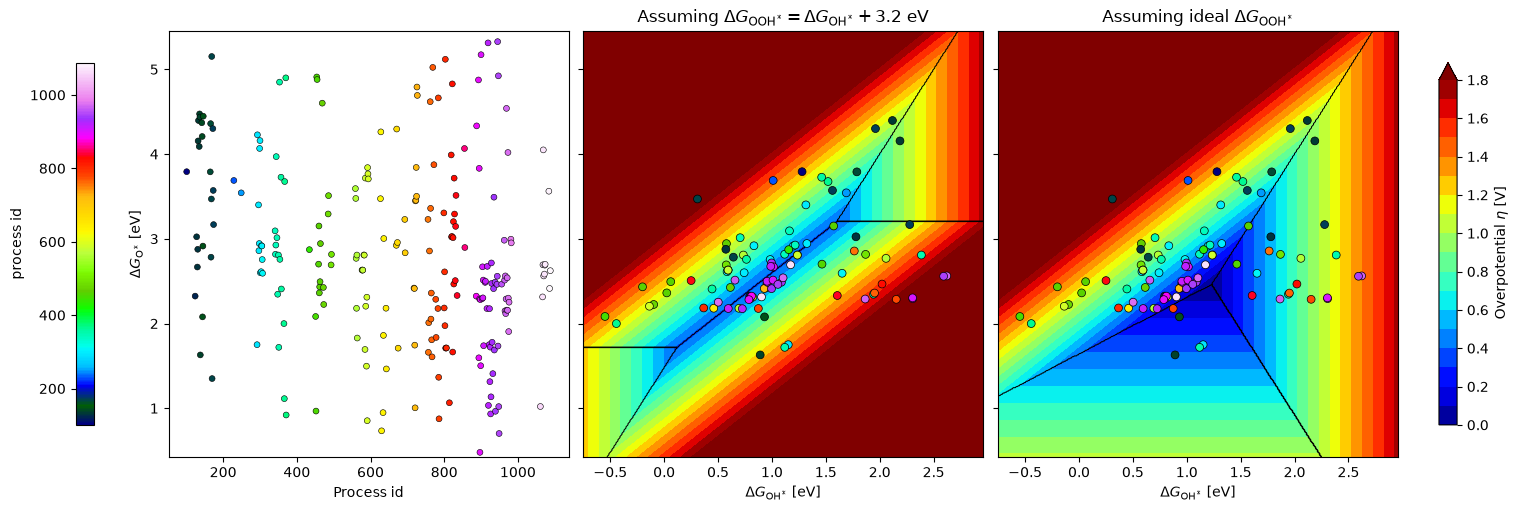

In [ ]:
PID_CMAP = "gist_ncar"  # sequential map for the process_id colouring (kept distinct from "jet")

site_points = both_df.merge(
    o_processes[["process_id", "candidate_id", "termination_index", "site_index"]],
    left_on=["candidate_id", "termination", "Site index"],
    right_on=["candidate_id", "termination_index", "site_index"],
    how="left",
)
assert site_points["process_id"].notna().all(), \
    "every site's G(O) should trace back to exactly one O_adsorption process"

pid_vmin, pid_vmax = o_processes["process_id"].min(), o_processes["process_id"].max()

x_lim = robust_limits(both_df["G(OH)"])
y_lim = robust_limits(pd.concat([o_processes["G(O)"], both_df["G(O)"]]))

resolution = 400
xs = np.linspace(*x_lim, resolution)
ys = np.linspace(*y_lim, resolution)
G_OH_grid, G_O_grid = np.meshgrid(xs, ys)

eta_scaling = oer_overpotential(G_OH_grid, G_O_grid, ooh_model=scaling_ooh)
eta_ideal = oer_overpotential(G_OH_grid, G_O_grid, ooh_model=ideal_ooh)

# One shared colour scale for panels 2 and 3, derived from both fields together.
step, eta_max = 0.1, 1.8
lo = np.floor(min(eta_scaling.min(), eta_ideal.min()) / step) * step
hi = min(np.ceil(max(eta_scaling.max(), eta_ideal.max()) / step) * step, eta_max)
levels = np.round(lo + step * np.arange(int(round((hi - lo) / step)) + 1), 2)


def draw_field(ax, eta, ooh_model, title, limiting_step_levels):
    extend = "max" if eta.max() > levels[-1] + 1e-9 else "neither"
    cf = ax.contourf(G_OH_grid, G_O_grid, eta, levels=levels, cmap="jet", extend=extend)
    lim = oer_limiting_step(G_OH_grid, G_O_grid, ooh_model=ooh_model)
    ax.contour(G_OH_grid, G_O_grid, lim, levels=limiting_step_levels,
               colors="black", linewidths=0.75)
    sc = ax.scatter(site_points["G(OH)"], site_points["G(O)"], c=site_points["process_id"],
                     cmap=PID_CMAP, vmin=pid_vmin, vmax=pid_vmax, s=32,
                     edgecolor="black", linewidth=0.5, zorder=5)
    ax.set_xlim(x_lim)
    ax.set_ylim(y_lim)
    ax.set_xlabel(r"$\Delta G_{\mathrm{OH^*}}$ [eV]")
    ax.set_title(title)
    return cf, sc


fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5), sharey=True,
                                     constrained_layout=True)

sc1 = ax1.scatter(o_processes["process_id"], o_processes["G(O)"],
                   c=o_processes["process_id"], cmap=PID_CMAP,
                   vmin=pid_vmin, vmax=pid_vmax, s=18,
                   edgecolor="black", linewidth=0.4)
ax1.set_xlabel("Process id")
ax1.set_ylabel(r"$\Delta G_{\mathrm{O^*}}$ [eV]")

# scaling_ooh has 4 distinct steps -> 3 boundaries; under ideal_ooh, steps 3 & 4
# (O*->OOH* and OOH*->O2) are mathematically tied everywhere by construction, so
# the 2.5 boundary between them is pure floating-point noise - only draw the two
# real boundaries (OH*-limited vs O*-limited vs OOH*-limited) for that panel.
draw_field(ax2, eta_scaling, scaling_ooh, r"Assuming $\Delta G_{\mathrm{OOH^*}} = \Delta G_{\mathrm{OH^*}} + 3.2$ eV",
           limiting_step_levels=np.arange(0.5, 4, 1))
cf, _ = draw_field(ax3, eta_ideal, ideal_ooh, r"Assuming ideal $\Delta G_{\mathrm{OOH^*}}$",
                    limiting_step_levels=[0.5, 1.5])
for ax in (ax2, ax3):
    ax.tick_params(labelleft=False)

fig.colorbar(cf, ax=[ax2, ax3], label=r"Overpotential $\eta$ [V]", shrink=0.85)
fig.colorbar(sc1, ax=[ax1, ax2, ax3], location="left",
             label="process id", shrink=0.85, pad=0.02)
plt.show()

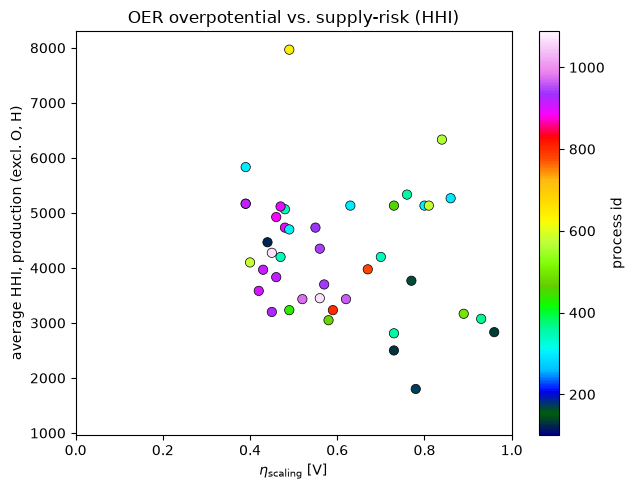

In [ ]:
## 8. Supply-chain risk (HHI) vs. overpotential

from aq_gnome import Data_Handler

overpotential_col = "eta_scaling" # "eta_scaling"  # or "eta_ideal"
color_by_process_id = True        # colour points by O_adsorption process_id (section 7's PID_CMAP) instead of a flat colour

# Production-concentration HHI, averaged over every element in the material,
# excluding O and H (both are ubiquitous and would just wash out the risk
# signal from the actually-scarce elements). Loaded fresh from the raw
# AQ-GNoME database (screened universe, ~529k materials) since this column
# isn't persisted onto EXPLOG's candidates table -- only "Reduced Formula"
# and the decomposition-energy column are (see src/aq_gnome_candidate_sync.py).
# We index straight into dh._working_df (skipping Data_Handler.get_df()'s
# defensive copy of all 32 columns) since we only need 2 of them and dh is
# dropped immediately after -- nobody else holds a reference to mutate.
dh = Data_Handler(solid_filter=True, gga_only=False, path_to_data_directory=None)
hhi_lookup = (dh._working_df[["MaterialId", "average_HHI_P_excluding_O_H"]]
                .set_index("MaterialId"))
del dh

hhi_df = leaderboard.merge(hhi_lookup, left_on="candidate_id", right_index=True, how="left")
n_missing = int(hhi_df["average_HHI_P_excluding_O_H"].isna().sum())
if n_missing:
    print(f"{n_missing} candidate(s) not found in the AQ-GNoME database -- dropped from the HHI plot.")
hhi_df = hhi_df.dropna(subset=["average_HHI_P_excluding_O_H"])

overpotential_label = {"eta_scaling": r"$\eta_{\mathrm{scaling}}$ [V]",
                       "eta_ideal": r"$\eta_{\mathrm{ideal}}$ [V]"}[overpotential_col]

fig, ax = plt.subplots(figsize=(6.5, 5))
if color_by_process_id:
    # Each leaderboard row is a candidate's best (candidate_id, termination, Site
    # index) triple -- the same key section 7 uses to trace a site back to its
    # originating O_adsorption process_id. o_processes/PID_CMAP/pid_vmin/pid_vmax
    # come from section 7, already in scope by the time this cell runs.
    hhi_df = hhi_df.merge(
        o_processes[["process_id", "candidate_id", "termination_index", "site_index"]],
        left_on=["candidate_id", "termination", "Site index"],
        right_on=["candidate_id", "termination_index", "site_index"],
        how="left",
    )
    sc = ax.scatter(hhi_df[overpotential_col], hhi_df["average_HHI_P_excluding_O_H"],
                     c=hhi_df["process_id"], cmap=PID_CMAP, vmin=pid_vmin, vmax=pid_vmax,
                     s=45, edgecolor="black", linewidth=0.5, zorder=5)
    fig.colorbar(sc, ax=ax, label="process id")
else:
    ax.scatter(hhi_df[overpotential_col], hhi_df["average_HHI_P_excluding_O_H"],
               s=45, color=BLUE, alpha=0.9, edgecolor="white", linewidth=0.6, zorder=5)
ax.set_xlabel(overpotential_label)
ax.set_ylabel("average HHI, production (excl. O, H)")
ax.set_title("OER overpotential vs. supply-risk (HHI)")
fig.tight_layout()

ax.set_xlim([0,1])

plt.show()


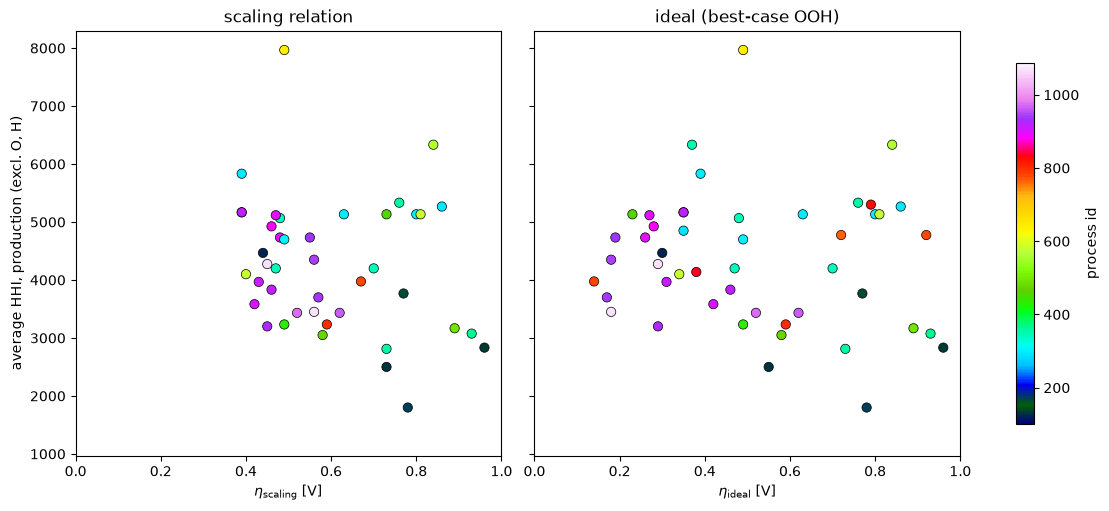

In [ ]:
## 9. Supply-chain risk (HHI): scaling vs. ideal overpotential, side by side

color_by_process_id = True  # colour points by O_adsorption process_id (section 7's PID_CMAP) instead of a flat colour

# Independent of section 8's hhi_df (whose columns depend on that cell's own
# color_by_process_id flag) -- rebuilt here from `leaderboard` + `hhi_lookup`,
# both already in scope (hhi_lookup was loaded once in section 8, no need to
# hit Data_Handler again).
hhi_both_df = leaderboard.merge(hhi_lookup, left_on="candidate_id", right_index=True, how="left")
hhi_both_df = hhi_both_df.dropna(subset=["average_HHI_P_excluding_O_H"])

if color_by_process_id:
    hhi_both_df = hhi_both_df.merge(
        o_processes[["process_id", "candidate_id", "termination_index", "site_index"]],
        left_on=["candidate_id", "termination", "Site index"],
        right_on=["candidate_id", "termination_index", "site_index"],
        how="left",
    )

panels = [("eta_scaling", r"$\eta_{\mathrm{scaling}}$ [V]", "scaling relation"),
          ("eta_ideal", r"$\eta_{\mathrm{ideal}}$ [V]", "ideal (best-case OOH)")]

# constrained_layout, not tight_layout: tight_layout doesn't reserve space
# correctly for one colorbar spanning two axes (it gets computed before the
# colorbar claims its slot, so a later fig.tight_layout() call squeezes/
# overlaps it) -- same reason section 7 uses constrained_layout for its
# multi-axis colorbars.
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True, constrained_layout=True)
sc = None
for ax, (col, xlabel, title) in zip(axes, panels):
    if color_by_process_id:
        sc = ax.scatter(hhi_both_df[col], hhi_both_df["average_HHI_P_excluding_O_H"],
                         c=hhi_both_df["process_id"], cmap=PID_CMAP, vmin=pid_vmin, vmax=pid_vmax,
                         s=45, edgecolor="black", linewidth=0.5, zorder=5)
    else:
        ax.scatter(hhi_both_df[col], hhi_both_df["average_HHI_P_excluding_O_H"],
                   s=45, color=BLUE, alpha=0.9, edgecolor="white", linewidth=0.6, zorder=5)
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.set_xlim([0, 1])

axes[0].set_ylabel("average HHI, production (excl. O, H)")
if color_by_process_id:
    fig.colorbar(sc, ax=axes, label="process id", shrink=0.85)
plt.show()


(0.0, 2.0)

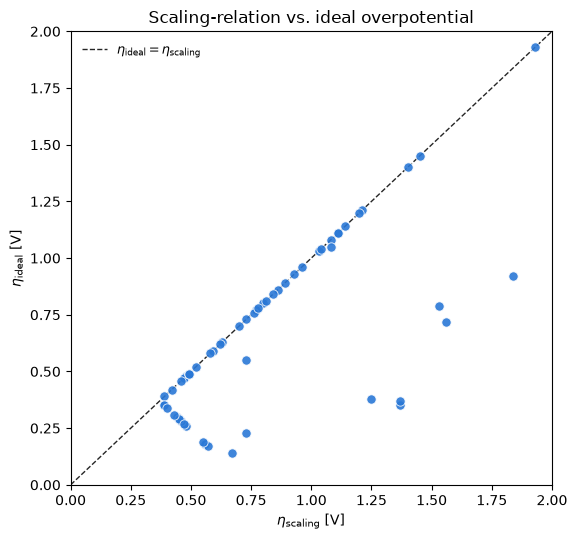

In [ ]:
## 10. Scaling-relation vs. ideal overpotential

# eta_ideal <= eta_scaling always (it's the loosest possible bound, achieved
# only if OOH* weren't constrained by the universal scaling relation -- see
# section 7); the dashed y=x line marks where the scaling relation costs
# nothing, so distance below it is the "tax" it imposes on each candidate.
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(leaderboard["eta_scaling"], leaderboard["eta_ideal"],
           s=45, color=BLUE, alpha=0.9, edgecolor="white", linewidth=0.6, zorder=5)

lims = [0, max(leaderboard["eta_scaling"].max(), leaderboard["eta_ideal"].max()) * 1.05]
ax.plot(lims, lims, color="0.15", ls="--", lw=1, label=r"$\eta_{\mathrm{ideal}} = \eta_{\mathrm{scaling}}$")


ax.set_xlabel(r"$\eta_{\mathrm{scaling}}$ [V]")
ax.set_ylabel(r"$\eta_{\mathrm{ideal}}$ [V]")
ax.set_title("Scaling-relation vs. ideal overpotential")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()

ax.set_xlim([0,2])
ax.set_ylim([0,2])

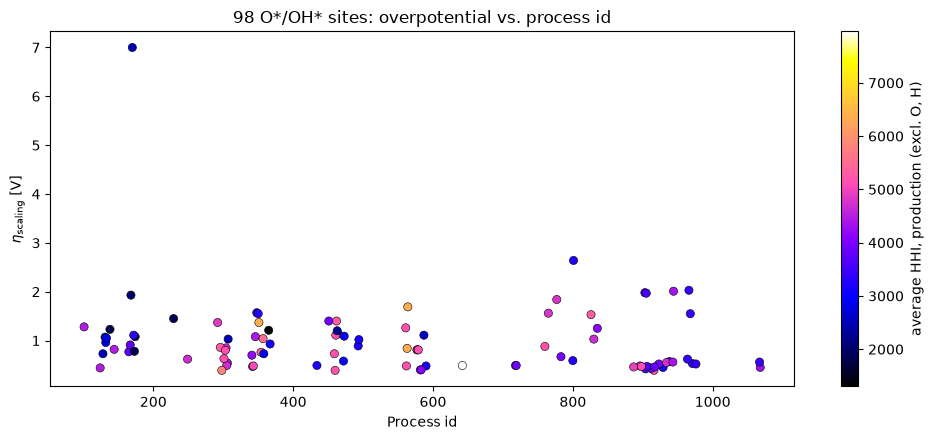

In [ ]:
## 11. Overpotential vs. process id, coloured by supply-chain risk (HHI)

overpotential_col = "eta_scaling"  # "eta_scaling"  # or "eta_ideal"

# Every site with both G(O) and G(OH) computed (both_df) -- not reduced to one
# best site per candidate like `leaderboard` -- joined to its originating
# O_adsorption process_id (section 7's join key) and to the AQ-GNoME HHI lookup
# (section 8's hhi_lookup, already in scope).
site_hhi_df = both_df.merge(
    o_processes[["process_id", "candidate_id", "termination_index", "site_index"]],
    left_on=["candidate_id", "termination", "Site index"],
    right_on=["candidate_id", "termination_index", "site_index"],
    how="left",
).rename(columns={
    "overpotential from OH-OOH scaling relation": "eta_scaling",
    "ideal overpotential": "eta_ideal",
})
site_hhi_df = site_hhi_df.merge(hhi_lookup, left_on="candidate_id", right_index=True, how="left")

n_missing = int(site_hhi_df[["process_id", "average_HHI_P_excluding_O_H"]].isna().any(axis=1).sum())
if n_missing:
    print(f"{n_missing} site(s) missing a process id or HHI value -- dropped from this plot.")
site_hhi_df = site_hhi_df.dropna(subset=["process_id", "average_HHI_P_excluding_O_H"])

HHI_CMAP = 'gnuplot2'  # continuous scale for average_HHI_P_excluding_O_H (kept distinct from PID_CMAP/"jet"/"cividis")
overpotential_label = {"eta_scaling": r"$\eta_{\mathrm{scaling}}$ [V]",
                       "eta_ideal": r"$\eta_{\mathrm{ideal}}$ [V]"}[overpotential_col]

fig, ax = plt.subplots(figsize=(10, 4.5))
sc = ax.scatter(site_hhi_df["process_id"], site_hhi_df[overpotential_col],
                 c=site_hhi_df["average_HHI_P_excluding_O_H"], cmap=HHI_CMAP,
                 s=35, edgecolor="black", linewidth=0.4, zorder=5)
fig.colorbar(sc, ax=ax, label="average HHI, production (excl. O, H)")
ax.set_xlabel("Process id")
ax.set_ylabel(overpotential_label)
ax.set_title(f"{len(site_hhi_df)} O*/OH* sites: overpotential vs. process id")
fig.tight_layout()
plt.show()


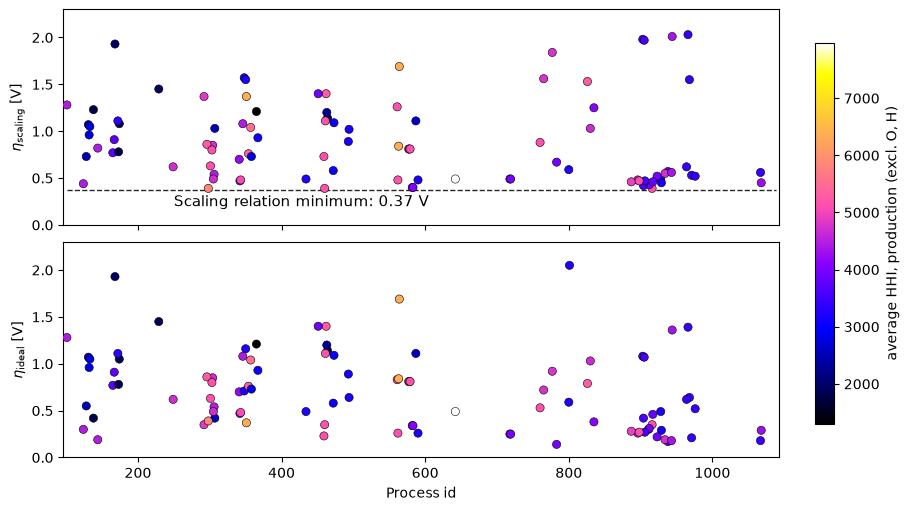

In [ ]:
## 12. Both overpotentials vs. process id, stacked vertically (shared x-axis)

# Reuses site_hhi_df/HHI_CMAP from section 11 -- unlike section 9 vs. section 8,
# nothing here mutates that frame based on a flag (overpotential_col there only
# picks which column to plot, not which rows/columns exist), so depending on it
# directly is safe.
panels = [("eta_scaling", r"$\eta_{\mathrm{scaling}}$ [V]"),
          ("eta_ideal", r"$\eta_{\mathrm{ideal}}$ [V]")]

fig, axes = plt.subplots(2, 1, figsize=(9, 5), sharex=True, constrained_layout=True)
sc = None
for ax, (col, ylabel) in zip(axes, panels):
    sc = ax.scatter(site_hhi_df["process_id"], site_hhi_df[col],
                     c=site_hhi_df["average_HHI_P_excluding_O_H"], cmap=HHI_CMAP,
                     s=35, edgecolor="black", linewidth=0.4, zorder=5)
    ax.set_ylabel(ylabel)

axes[-1].set_xlabel("Process id")
fig.colorbar(sc, ax=axes, label="average HHI, production (excl. O, H)", shrink=0.85)

axes[0].plot([pid_vmin, pid_vmax], [0.37,0.37], color="0.15", ls="--", lw=1, label=r"$\eta_{\mathrm{max}} = 1.8$ V")
axes[0].text(250, 0.2, 'Scaling relation minimum: 0.37 V', fontsize=11, color='k')

for ax in axes:
    ax.set_ylim([0, 2.3])
    ax.set_xlim([pid_vmin-5, pid_vmax+5])

plt.show()
